In [9]:
import pandas as pd

df = pd.read_csv("../data/processed/telco_features.csv")
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,TotalServices,AvgMonthlyValue,ContractRisk,AutoPay,EngagementScore,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_Mid,TenureGroup_New
0,0,1,29.85,29.85,0,1,14.925000,2,1,0.083333,...,False,False,False,False,True,False,True,False,False,True
1,0,34,56.95,1889.50,0,3,53.985714,1,1,8.833333,...,False,False,True,False,False,False,False,True,True,False
2,0,2,53.85,108.15,1,3,36.050000,2,1,4.166667,...,False,False,False,False,True,False,False,True,False,True
3,0,45,42.30,1840.75,0,3,40.016304,1,0,9.750000,...,False,False,True,False,False,False,False,False,False,False
4,0,2,70.70,151.65,1,1,50.550000,2,1,0.166667,...,False,False,False,False,True,False,True,False,False,True


In [14]:
seg_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "TotalServices",
    "EngagementScore",
    "AvgMonthlyValue",
    "ContractRisk",
    "AutoPay",
    "HighValue"
]

X = df[seg_features].copy()

# Handle missing safely
X = X.fillna(X.median())

# Scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

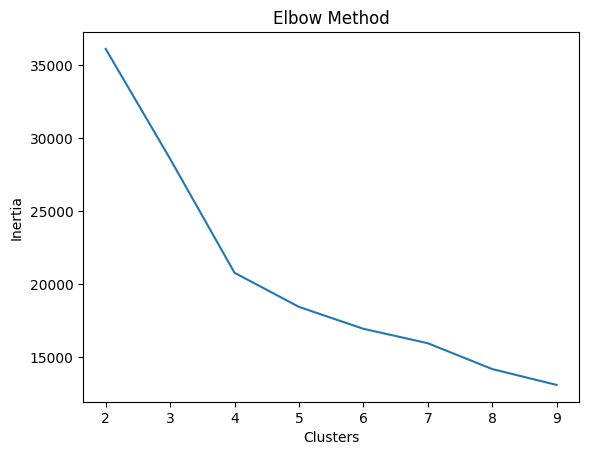

In [15]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2,10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2,10), inertia)
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [16]:
from sklearn.metrics import silhouette_score

for k in range(2,7):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    print(k, silhouette_score(X_scaled, labels))

2 0.36806535153135805
3 0.3134890774775281
4 0.35058764923083846
5 0.31096022868201206
6 0.30855021300477853


In [17]:
kmeans = KMeans(n_clusters=4, random_state=42)
df["Segment"] = kmeans.fit_predict(X_scaled)

/var/folders/r1/g3516kxn1gj1yq06vw004m5h0000gn/T/ipykernel_14809/3730193081.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Segment"] = kmeans.fit_predict(X_scaled)


In [18]:
df.to_csv("../data/processed/telco_segmented.csv", index=False)

In [19]:
df["Segment"].value_counts()

Segment
1    2010
2    1971
3    1635
0    1427
Name: count, dtype: int64

In [20]:
segment_profile = df.groupby("Segment")[seg_features].mean()
segment_profile

,tenure,MonthlyCharges,TotalCharges,TotalServices,EngagementScore,AvgMonthlyValue,ContractRisk,AutoPay,HighValue
Segment,,,,,,,,,
0,48.866153,37.381605,1806.828617,2.419762,9.915207,36.430727,0.498248,0.341976,0.000701
1,10.851741,38.928085,411.834157,1.593532,2.450580,30.683213,1.820398,0.776617,0.013433
2,19.122273,85.766870,1657.185932,3.616946,6.994842,75.751177,1.916286,0.714358,0.973110
3,60.401223,95.095474,5746.134557,6.055046,17.827319,93.548345,0.658104,0.318043,0.959633


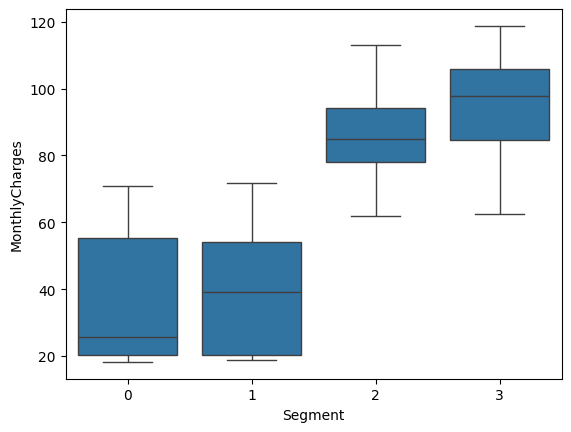

In [21]:
import seaborn as sns

sns.boxplot(x="Segment", y="MonthlyCharges", data=df)
plt.show()

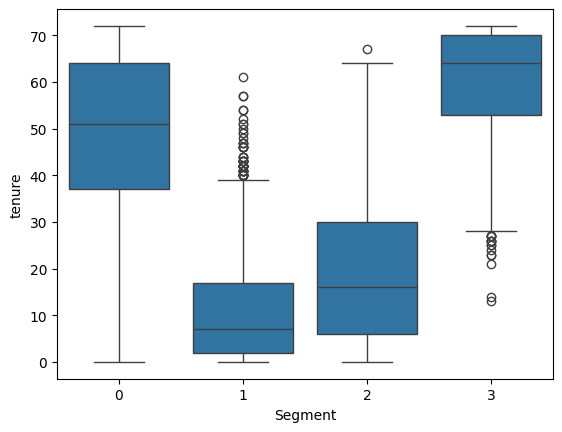

In [22]:
sns.boxplot(x="Segment", y="tenure", data=df)
plt.show()

In [23]:
import joblib

joblib.dump(kmeans, "../models/kmeans_segmentation.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']